In [9]:
# Iris Dataset - Exploratory Analysis and Classification 
## Summary 
#    - Dataset: Iris (150 samples, 4 features, 3 species)
#    - no missing values found 
#    - random forest classifier reached 100% test accuracy 
#    - petal length and width are the strongest predictors of speices 

## Skills demonstrated 
# - exploratory data analysis 
# - data visualization 
# - classification modeling with scikit-learn
# - feature importance interpretation 

In [1]:
import pandas as pd 
from sklearn.datasets import load_iris

df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)

print(df.shape)
print(df.head())


(150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


Matplotlib is building the font cache; this may take a moment.


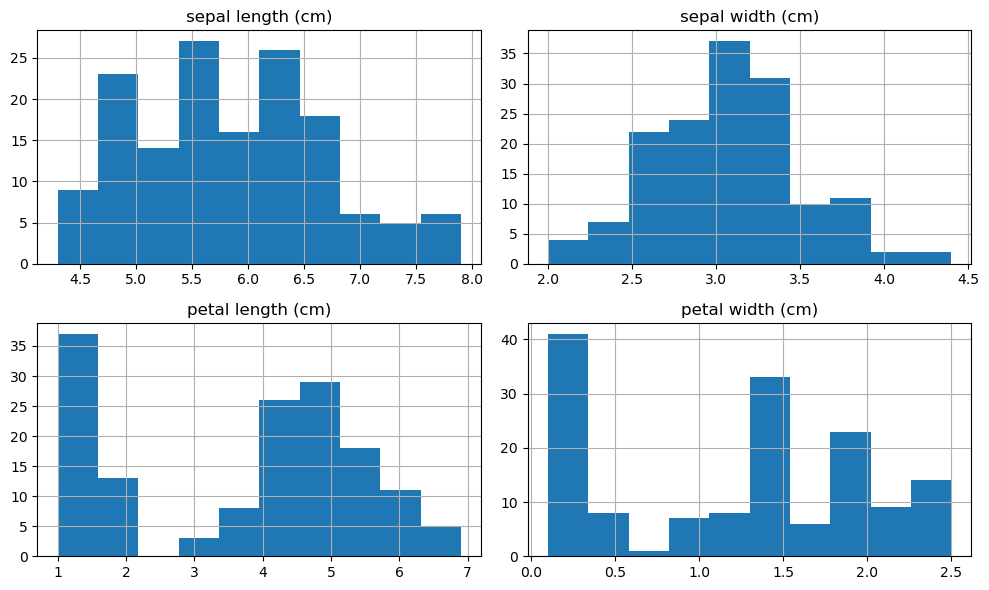

In [3]:
import matplotlib.pyplot as plt 

df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

In [4]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [5]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [6]:
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# add target 
df['target'] = load_iris().target

#split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#train 
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

#evaluate
preds = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")


Accuracy: 1.00


In [7]:
import numpy as np 
#feature importance 
importances = model.feature_importances_
features = X.columns

for feat, imp in sorted(zip(features, importances), key=lambda x: x[1], reverse= True): 
    print(f"{feat}: {imp:.3f}")

petal length (cm): 0.440
petal width (cm): 0.422
sepal length (cm): 0.108
sepal width (cm): 0.030


In [11]:
import pkg_resources
pkgs = ['pandas','numpy', 'matplotlib', 'scikit-learn']
for p in pkgs:
        print(f"{p}={pkg_resources.get_distribution(p).version}")

pandas=2.2.3
numpy=2.1.3
matplotlib=3.10.0
scikit-learn=1.6.1


/var/folders/lq/_tl2ntzx64jfq19bd8b83vwc0000gn/T/ipykernel_9751/3853809414.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
